# AssemLens • larger controlled run
Based on committed run `fc83aef`. Keep the existing environment that passed on GB10; **do not rerun the old uv setup**.

The uploaded outputs show a completed **v1** run: 76 optimizer steps, 2 epochs, training runtime 277.0846 seconds, training loss 0.5787483; a nearby validation evaluation has loss 0.3454418. Adapted generation on 40 examples: action 0%, verb 12.5%, object 7.5%, valid JSON 100%. The full-run baseline and final comparison file were not visible in the saved outputs, so improvement over the base model cannot be established. A two-example pilot is not evidence of accuracy.

The larger preparation cell selected 2,472 train segments / 589 validation segments from 24/4 recordings (22.59 GiB videos), but later cells redirected ROOT back to `assembly101_v1`. The extraction output ends before a completion summary. We cannot establish that v2 data was trained. The checked-in script now says 8 epochs and 300-step evaluation; the completed log says 2 epochs and includes step-75 evaluation, demonstrating code/output drift.

**Next experiment:** scale recording diversity, keep the same 4B model and rank-16 BF16 LoRA, use 3 epochs at 5e-5, evaluate/checkpoint every 50 steps, early stop after 3 evaluations without loss improvement, restore best loss checkpoint. Default 32 train / 8 validation recordings, up to 180 examples each; actual counts depend on annotations. A 45-GiB video budget bounds downloads, not total disk. Existing HF video cache is reused. New root at repository `runs/assembly101_scale_v3`; old runs remain untouched.

Generation evaluation uses up to 160 examples spread across validation recordings; periodic loss uses up to 256. Final loss covers all validation examples. Train-label coverage, supported-label macro F1, predictions, generation latency and actual training arguments are saved. Generation timing excludes preprocessing and is **not end-to-end UI latency**. Results are still action recognition, not product error verification. Two sparse frames and vocabulary mismatch can limit performance even with more data.

Run sequentially, inspect frames, pass the fresh pilot, then launch. The worker has CPU-tested sampling/metric logic and syntax checks, but this new run has not been GPU-tested here. Do not run alongside another GPU job.


In [2]:
import sys, platform, shutil, subprocess, json, os, time
from pathlib import Path
import torch
REPO = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p/'scripts/train_assemlens_v2.py').is_file()), None)
assert REPO, 'Open this notebook from the updated cloned repository.'
assert Path(sys.prefix).resolve() == (REPO/'.venv').resolve(), 'Select the project .venv kernel.'
assert torch.cuda.is_available() and torch.cuda.is_bf16_supported()
x=torch.randn(512,512,device='cuda',dtype=torch.bfloat16)
assert torch.isfinite(x@x).all().item()
del x; torch.cuda.empty_cache()
print(sys.executable, torch.__version__, torch.cuda.get_device_name(0))
ROOT=REPO/'runs'/'assembly101_scale_v3'
ROOT.mkdir(parents=True,exist_ok=True)
FFMPEG=shutil.which('ffmpeg') or str(Path.home()/'miniforge3/envs/assemlens-media/bin/ffmpeg')
assert Path(FFMPEG).is_file(), 'Set FFMPEG to your installed executable.'
CFG=dict(root=str(ROOT), model='Qwen/Qwen3-VL-4B-Instruct',dataset='cvml-nus/assembly101',
         camera='C10404_rgb.mp4', train_recordings=32,validation_recordings=8,
         segments_per_recording=180,video_budget_gib=45,image_side=448,
         training_hours=6,epochs=3,learning_rate=5e-5,eval_steps=50,
         generation_eval_samples=160,loss_eval_samples=256)
print(json.dumps(CFG,indent=2))
print('Free disk GiB:',round(shutil.disk_usage(ROOT).free/2**30,1))


/home/hp15/git_happens/assemlens/.venv/bin/python 2.14.0+cu130 NVIDIA GB10
{
  "root": "/home/hp15/git_happens/assemlens/runs/assembly101_scale_v3",
  "model": "Qwen/Qwen3-VL-4B-Instruct",
  "dataset": "cvml-nus/assembly101",
  "camera": "C10404_rgb.mp4",
  "train_recordings": 32,
  "validation_recordings": 8,
  "segments_per_recording": 180,
  "video_budget_gib": 45,
  "image_side": 448,
  "training_hours": 6,
  "epochs": 3,
  "learning_rate": 5e-05,
  "eval_steps": 50,
  "generation_eval_samples": 160,
  "loss_eval_samples": 256
}
Free disk GiB: 3383.6


## Inspect the old run's actual results (optional, read-only)
This resolves the stale “No final report yet” cell if the report now exists on the HP. Exact-match can reject synonyms; inspect prediction text and labels together. Don't infer improvement from low training loss alone.


In [3]:
previous=REPO/'notebooks/runs/assembly101_v1/overnight'
for name in ['comparison.json','baseline.json','adapted.json']:
    p=previous/name
    if p.exists():
        obj=json.loads(p.read_text())
        print(name, json.dumps(obj.get('metrics',obj if name=='comparison.json' else {}),indent=2))
        if name=='adapted.json':
            for r in obj.get('predictions',[])[:8]: print('LABEL:',r['target'],'PREDICTION:',r['prediction'])
    else: print('Not found:',p)


comparison.json {
  "baseline": {
    "action_exact_match": 0.0,
    "verb_exact_match": 0.0,
    "object_exact_match": 0.025,
    "valid_json_fraction": 1.0,
    "n": 40
  },
  "adapted": {
    "action_exact_match": 0.0,
    "verb_exact_match": 0.125,
    "object_exact_match": 0.075,
    "valid_json_fraction": 1.0,
    "n": 40
  },
  "validation_loss": {
    "eval_loss": 0.3452145457267761,
    "eval_runtime": 22.2185,
    "eval_samples_per_second": 7.201,
    "eval_steps_per_second": 7.201,
    "epoch": 2.0
  },
  "scope": "action recognition on held-out recordings; not furniture defect detection"
}
baseline.json {
  "action_exact_match": 0.0,
  "verb_exact_match": 0.0,
  "object_exact_match": 0.025,
  "valid_json_fraction": 1.0,
  "n": 40
}
adapted.json {
  "action_exact_match": 0.0,
  "verb_exact_match": 0.125,
  "object_exact_match": 0.075,
  "valid_json_fraction": 1.0,
  "n": 40
}
LABEL: {'action': 'inspect diagram', 'verb': 'inspect', 'object': 'diagram'} PREDICTION: {'action': 

## Authenticate and lock revisions
Use the cached HF token. The official [Assembly101 download](https://huggingface.co/datasets/cvml-nus/assembly101) requires accepted access conditions (CC BY-NC 4.0). No unrestricted wget bypass is offered. The download calls below retrieve only selected files. Preserve config and model revision on reruns.


In [4]:
from huggingface_hub import HfApi, hf_hub_download, login, get_token
from getpass import getpass
if not get_token():
    login(token=getpass('Hugging Face read token: '), add_to_git_credential=False)
api = HfApi()
config_path=ROOT/'config.json'
if config_path.exists():
    saved=json.loads(config_path.read_text())
    assert all(saved.get(k)==v for k,v in CFG.items()), 'Configuration changed: choose a new ROOT.'
    CFG=saved
else:
    CFG['dataset_revision']=api.dataset_info(CFG['dataset']).sha
    CFG['model_revision']=api.model_info(CFG['model']).sha
# A small authorized download proves access before downloading any videos.
actions_path = hf_hub_download(CFG['dataset'], 'annotations/fine-grained-annotations/actions.csv',
                               repo_type='dataset', revision=CFG['dataset_revision'])
print('Access verified. Dataset revision:', CFG['dataset_revision'])
(ROOT / 'config.json').write_text(json.dumps(CFG, indent=2))
# Freeze installed package versions for the experiment; no credentials in this command.
(ROOT / 'environment.txt').write_text(subprocess.check_output([sys.executable, '-m', 'pip', 'freeze'], text=True))


/home/hp15/miniforge3/envs/zgx/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Access verified. Dataset revision: bfc15ea5e3f0bc8f8c232af6c1b45aa137a9d967


13620

## Select recordings and check budget
Use official split labels, one camera and full-recording separation. Keep test untouched. Selection is deterministic; increasing recording counts retains a prefix of the earlier selected recordings, reusing cached videos. This is not class-balanced sampling. Annotation frame positions use 30 fps.


In [5]:
import pandas as pd
import random
columns = ['id','video','start_frame','end_frame','action_cls','verb_cls','noun_cls']
tables = {}
for split in ['train','validation']:
    path = hf_hub_download(CFG['dataset'], f'annotations/fine-grained-annotations/{split}.csv',
                           repo_type='dataset', revision=CFG['dataset_revision'])
    df = pd.read_csv(path, usecols=columns).dropna()
    df = df[df.video.str.endswith('/'+CFG['camera'])].copy()
    df['sequence'] = df.video.str.split('/').str[0]
    duration = (df.end_frame - df.start_frame)/30.0
    df = df[(duration >= 1.0) & (duration <= 30.0)].copy()
    tables[split] = df
# Exclude all official validation recording identities from the training pool.
val_sequences = set(tables['validation'].sequence)
tables['train'] = tables['train'][~tables['train'].sequence.isin(val_sequences)].copy()
selected = {}
for split in ['train','validation']:
    df = tables[split]
    sequences = sorted(df.sequence.unique())
    random.Random(42).shuffle(sequences)
    sequences = sequences[:CFG[split+'_recordings']]
    assert len(sequences) >= (2 if split == 'train' else 1), f'Too few {split} recordings.'
    selected[split] = pd.concat([df[df.sequence == seq].sample(n=min(CFG['segments_per_recording'], len(df[df.sequence == seq])), random_state=42) for seq in sequences]).sort_values(['video','start_frame'])
assert not (set(selected['train'].sequence) & set(selected['validation'].sequence))
video_plan=[]
for video in sorted(set(pd.concat(list(selected.values())).video)):
    sequence, camera = video.split('/')
    repo_path = 'recordings/'+video
    entries = list(api.list_repo_tree(CFG['dataset'], path_in_repo='recordings/'+sequence,
                                     repo_type='dataset', revision=CFG['dataset_revision']))
    matches=[e for e in entries if e.path == repo_path]
    assert len(matches)==1 and matches[0].size > 0, f'Missing video metadata: {repo_path}'
    video_plan.append(dict(video=video, path=repo_path, bytes=matches[0].size))
size=sum(v['bytes'] for v in video_plan)
print('Video download GiB:',round(size/2**30,2))
print({s:dict(recordings=int(d.sequence.nunique()), segments=len(d)) for s,d in selected.items()})
assert size <= CFG['video_budget_gib']*2**30, 'Budget exceeded: reduce recording counts and rerun selection. No videos downloaded yet.'
(ROOT/'video_plan.json').write_text(json.dumps(video_plan,indent=2))
for split, df in selected.items(): df.to_csv(ROOT/f'{split}_selection.csv',index=False)

assert shutil.disk_usage(ROOT).free > size + 15*2**30, 'Conservative free-space gate: reserve planned videos plus 15 GiB for frames/model/checkpoints.'


Video download GiB: 31.0
{'train': {'recordings': 32, 'segments': 3322}, 'validation': {'recordings': 8, 'segments': 995}}


## Download and extract frames
This preparation cell can take time. It decodes images at timestamps and resizes them. The new config explicitly supplies `image_side`, which was missing from the edited v2 configuration. Finish this cell before proceeding; partial frame extraction is not a ready dataset.


In [6]:
from PIL import Image, ImageOps, ImageDraw
import hashlib
videos={}
for i, item in enumerate(video_plan, 1):
    print(f'Downloading {i}/{len(video_plan)}:', item['video'], flush=True)
    videos[item['video']] = hf_hub_download(CFG['dataset'], item['path'], repo_type='dataset', revision=CFG['dataset_revision'])

def extract_frame(video, seconds, destination):
    destination=Path(destination)
    if destination.exists():
        with Image.open(destination) as im: im.verify()
        return
    temp=destination.with_suffix('.tmp.png')
    cmd=[FFMPEG,'-hide_banner','-loglevel','error','-y','-ss',f'{seconds:.4f}',
         '-i',str(video),'-frames:v','1',str(temp)]
    result=subprocess.run(cmd,capture_output=True,text=True,timeout=90)
    if result.returncode or not temp.exists():
        raise RuntimeError('Frame extraction failed: '+result.stderr[-500:])
    with Image.open(temp) as im:
        im=im.convert('RGB'); im.thumbnail((CFG['image_side'],CFG['image_side']))
        im.save(destination,quality=92)
    temp.unlink()

manifests={}; failures=[]
for split, df in selected.items():
    folder=ROOT/'frames'/split; folder.mkdir(parents=True,exist_ok=True)
    rows=[]
    for number, row in enumerate(df.itertuples(),1):
        key=hashlib.sha256(f'{split}:{row.video}:{row.id}:{row.start_frame}:{row.end_frame}'.encode()).hexdigest()[:20]
        start,end=row.start_frame/30.0,row.end_frame/30.0
        paths=[folder/f'{key}_{i}.jpg' for i in range(2)]
        try:
            for path, frac in zip(paths,[0.2,0.8]): extract_frame(videos[row.video],start+(end-start)*frac,path)
            rows.append(dict(id=key,sequence=row.sequence,video=row.video,start_seconds=start,end_seconds=end,
                             images=[str(p) for p in paths],target=dict(action=row.action_cls,verb=row.verb_cls,object=row.noun_cls)))
        except Exception as e:
            failures.append(dict(split=split,id=key,error=str(e)))
        if number%40==0: print(split,number,'/',len(df),flush=True)
    assert len(rows) >= 8, 'Too few decoded examples.'
    assert len(rows) >= 0.9*len(df), 'More than 10% failed to decode: inspect alignment/FFmpeg before training.'
    manifests[split]=rows
    (ROOT/f'{split}.jsonl').write_text(''.join(json.dumps(r)+'\n' for r in rows))
(ROOT/'decode_failures.json').write_text(json.dumps(failures,indent=2))
print('Prepared:',{s:len(r) for s,r in manifests.items()},'| decode failures:',len(failures))


train 40 / 3322
train 80 / 3322
train 120 / 3322
train 160 / 3322
train 200 / 3322
train 240 / 3322
train 280 / 3322
train 320 / 3322
train 360 / 3322
train 400 / 3322
train 440 / 3322
train 480 / 3322
train 520 / 3322
train 560 / 3322
train 600 / 3322
train 640 / 3322
train 680 / 3322
train 720 / 3322
train 760 / 3322
train 800 / 3322
train 840 / 3322
train 880 / 3322
train 920 / 3322
train 960 / 3322
train 1000 / 3322
train 1040 / 3322
train 1080 / 3322
train 1120 / 3322
train 1160 / 3322
train 1200 / 3322
train 1240 / 3322
train 1280 / 3322
train 1320 / 3322
train 1360 / 3322
train 1400 / 3322
train 1440 / 3322
train 1480 / 3322
train 1520 / 3322
train 1560 / 3322
train 1600 / 3322
train 1640 / 3322
train 1680 / 3322
train 1720 / 3322
train 1760 / 3322
train 1800 / 3322
train 1840 / 3322
train 1880 / 3322
train 1920 / 3322
train 1960 / 3322
train 2000 / 3322
train 2040 / 3322
train 2080 / 3322
train 2120 / 3322
train 2160 / 3322
train 2200 / 3322
train 2240 / 3322
train 2280 / 3322


In [7]:
assert len(manifests['train'])>=1000, 'Unexpectedly small training set: inspect selection and extraction.'
assert len({r['sequence'] for r in manifests['validation']})>=4
print('Ready dataset:',len(manifests['train']),len(manifests['validation']))
print('Approximate planned optimizer steps:',__import__('math').ceil(len(manifests['train'])/8)*CFG['epochs'])


Ready dataset: 3322 995
Approximate planned optimizer steps: 1248


## Visual label check
Check chronology, visibility and action labels before spending compute. Repeated similar images are expected within a session, but labels should describe the visible activity. Furniture-state annotations are still a separate next stage.


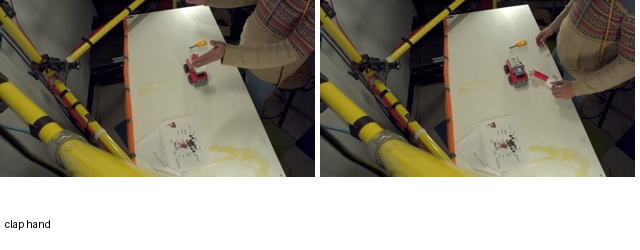

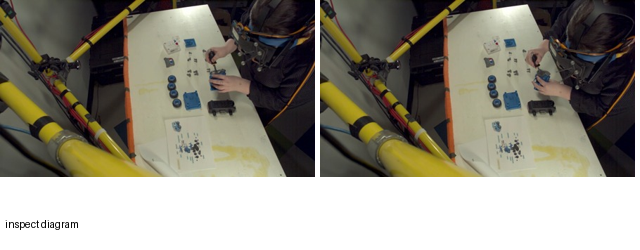

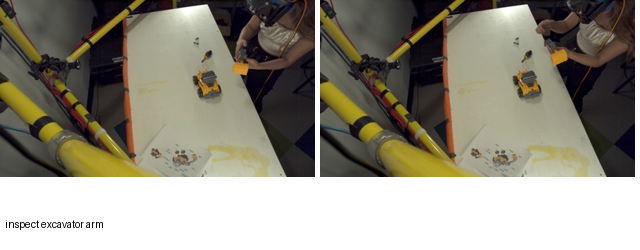

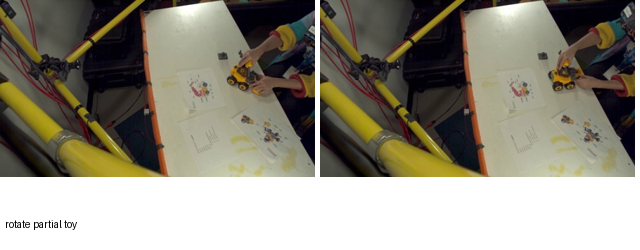

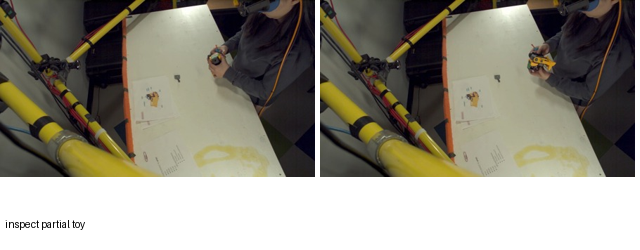

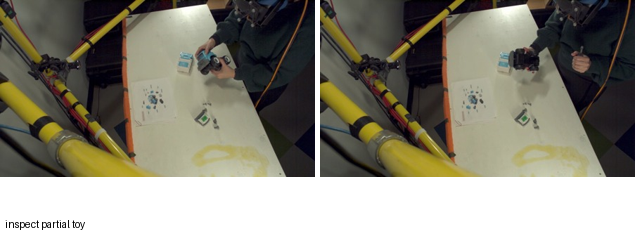

In [8]:
from IPython.display import display
for row in manifests['train'][::max(1,len(manifests['train'])//6)][:6]:
    canvas=Image.new('RGB',(640,250),'white')
    for i,path in enumerate(row['images']):
        with Image.open(path) as im:
            tile=ImageOps.contain(im.convert('RGB'),(315,210)); canvas.paste(tile,(i*320,0))
    ImageDraw.Draw(canvas).text((5,218),row['target']['action'],fill='black')
    display(canvas)


## Freeze this run's worker and run a fresh pilot
The worker snapshot is immutable within this run. Resume signatures include full records, config and worker hash. The BF16-only TorchAO-dispatch workaround from your successful run is retained; this is not a quantized-training recipe. The pilot uses a separate folder and four validation examples. It verifies execution, not model quality.


In [9]:
WORKER=ROOT/'train_assemlens_v2.py'
worker_source=(REPO/'scripts/train_assemlens_v2.py').read_text()
if WORKER.exists():
    assert WORKER.read_text()==worker_source, 'Worker changed: use a new run ROOT.'
else: WORKER.write_text(worker_source)
pilot_status=ROOT/'pilot/status.json'
if pilot_status.exists() and json.loads(pilot_status.read_text()).get('state')=='finished':
    print('Existing pilot passed in this fixed run directory.')
else:
    with (ROOT/'pilot.log').open('a') as log:
        result=subprocess.run([sys.executable,'-u',str(WORKER),'--config',str(ROOT/'config.json'),'--pilot'],stdout=log,stderr=subprocess.STDOUT)
    print((ROOT/'pilot.log').read_text()[-12000:])
    assert result.returncode==0,'Pilot failed: inspect pilot.log before launching.'
assert json.loads(pilot_status.read_text())['state']=='finished'


W0922 23:41:21.032000 999713 site-packages/torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W0922 23:41:21.048000 999713 site-packages/torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.

Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00, 116.66it/s]
trainable params: 11,796,480 || all params: 4,449,612,288 || trainable%: 0.2651
Run root: /home/hp15/git_happens/assemlens/runs/assembly101_scale_v3 Train: 16 Validation: 4 Generation eval: 4
The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more de

## Launch once
Two epochs on the original tiny set took minutes; “overnight” is not a required duration. This run stops after its epoch/early-stop/time budget. Baseline generation, downloads and final evaluation are outside the six-hour training budget. SSH disconnection can be tolerated by the detached worker, subject to lab policy. The HP must stay on.

Check that no other training/serving job is running first. Re-running this cell during startup is guarded by the stored PID; the worker also holds a run lock. A failed/interrupted run can resume the last checkpoint (at most 50 optimizer steps lost). Do not edit config/data/code while it runs.


In [10]:
assert json.loads((ROOT/'pilot/status.json').read_text())['state']=='finished'
status_path=ROOT/'overnight/status.json'
if status_path.exists():
    assert json.loads(status_path.read_text()).get('state')!='finished','Completed: inspect report, do not relaunch.'
pidfile=ROOT/'worker_pid.txt'
if pidfile.exists():
    try: os.kill(int(pidfile.read_text()),0)
    except ProcessLookupError: pass
    else: raise RuntimeError('Stored PID still exists. Inspect that process before launching another worker.')
with (ROOT/'overnight.log').open('a') as log:
    process=subprocess.Popen([sys.executable,'-u',str(WORKER),'--config',str(ROOT/'config.json')],stdin=subprocess.DEVNULL,stdout=log,stderr=subprocess.STDOUT,start_new_session=True)
pidfile.write_text(str(process.pid))
print('PID:',process.pid,'Run:',ROOT)


PID: 999812 Run: /home/hp15/git_happens/assemlens/runs/assembly101_scale_v3


In [15]:
# Monitor without starting another job.
if (ROOT/'overnight/status.json').exists(): print((ROOT/'overnight/status.json').read_text())
p=ROOT/'overnight.log'
if p.exists():
    with p.open('rb') as f:
        f.seek(max(0,p.stat().st_size-10000)); print(f.read().decode(errors='replace'))


{
  "state": "training",
  "pid": 999812,
  "resume_from": null
}
100%|██████████| 995/995 [02:23<00:00,  6.94it/s]



## Results and error analysis
The saved adapter is the lowest periodic validation-loss checkpoint when one exists; otherwise the final state. Loss-based selection is not guaranteed to maximize action accuracy. Compare base/adapted generation on identical, session-spread samples. Macro F1 covers labels present in that evaluated subset. Report sample/recording counts and seen-label coverage. Do not compare percentages directly to the old first-40 subset as if the evaluation set were identical.

If JSON is valid but semantic accuracy remains weak, inspect vocabulary synonyms, alignment, image resolution and temporal evidence before expanding again. Use your final target-product footage for the correction task. This benchmark supplies known action boundaries and does not measure online segmentation.


In [16]:
import pandas as pd
out=ROOT/'overnight'
assert (out/'comparison.json').exists(), 'Job not finished or failed; inspect status and log.'
report=json.loads((out/'comparison.json').read_text())
print(json.dumps(report,indent=2))
display(pd.DataFrame({'base':report['baseline'],'adapted':report['adapted']}))
print('Train-label coverage:',(out/'coverage.json').read_text())
errors=json.loads((out/'adapted.json').read_text())['predictions']
for r in errors[:20]: print(r['sequence'], '\nLABEL:',r['target'],'\nPRED:',r['prediction'],'\n')
# Small reproducible report bundle: JSON/versions/code only, no images/weights/tokens.
import zipfile
bundle=ROOT/'review_bundle.zip'
with zipfile.ZipFile(bundle,'w',zipfile.ZIP_DEFLATED) as z:
    for name in ['comparison.json','baseline.json','adapted.json','coverage.json','training_arguments.json','evaluation_ids.json','trainer_state.json']:
        p=out/name
        if p.exists(): z.write(p,'results/'+name)
    for name in ['config.json','environment.txt','train_assemlens_v2.py']:
        z.write(ROOT/name,name)
print('Share this bundle for analysis:',bundle)
print('Back up trained weights separately:',out/'adapter')


{
  "baseline": {
    "action_exact_match": 0.0,
    "verb_exact_match": 0.00625,
    "object_exact_match": 0.0,
    "valid_json_fraction": 1.0,
    "n": 160,
    "action_macro_f1_supported_labels": 0.0,
    "verb_macro_f1_supported_labels": 0.005263157894736842,
    "object_macro_f1_supported_labels": 0.0,
    "generation_seconds_p50": 1.287716402002843,
    "generation_seconds_p95": 1.4269892620068276,
    "recordings": 8
  },
  "adapted": {
    "action_exact_match": 0.13125,
    "verb_exact_match": 0.26875,
    "object_exact_match": 0.24375,
    "valid_json_fraction": 1.0,
    "n": 160,
    "action_macro_f1_supported_labels": 0.05178317053317053,
    "verb_macro_f1_supported_labels": 0.18252129424280047,
    "object_macro_f1_supported_labels": 0.11071598679957813,
    "generation_seconds_p50": 1.3911398220079718,
    "generation_seconds_p95": 1.5657283399923472,
    "recordings": 8
  },
  "validation_loss": {
    "eval_loss": 0.24269282817840576,
    "eval_runtime": 143.4704,
    "e

,base,adapted
action_exact_match,0.000000,0.131250
verb_exact_match,0.006250,0.268750
object_exact_match,0.000000,0.243750
valid_json_fraction,1.000000,1.000000
n,160.000000,160.000000
action_macro_f1_supported_labels,0.000000,0.051783
verb_macro_f1_supported_labels,0.005263,0.182521
object_macro_f1_supported_labels,0.000000,0.110716
generation_seconds_p50,1.287716,1.391140
generation_seconds_p95,1.426989,1.565728


Train-label coverage: {
  "action": 0.91875,
  "verb": 1.0,
  "object": 0.96875
}
nusar-2021_action_both_9022-b06c_9022_user_id_2021-02-03_114112 
LABEL: {'action': 'pick up nut', 'verb': 'pick up', 'object': 'nut'} 
PRED: {'action': 'put down partial toy', 'verb': 'put down', 'object': 'partial toy'} 

nusar-2021_action_both_9025-c06b_9025_user_id_2021-02-03_160657 
LABEL: {'action': 'inspect partial toy', 'verb': 'inspect', 'object': 'partial toy'} 
PRED: {'action': 'inspect partial toy', 'verb': 'inspect', 'object': 'partial toy'} 

nusar-2021_action_both_9031-c04d_9031_user_id_2021-02-04_104130 
LABEL: {'action': 'unscrew first wheel with screwdriver', 'verb': 'unscrew', 'object': 'first wheel'} 
PRED: {'action': 'put down partial toy', 'verb': 'put down', 'object': 'partial toy'} 

nusar-2021_action_both_9031-c06c_9031_user_id_2021-02-23_164844 
LABEL: {'action': 'inspect partial toy', 'verb': 'inspect', 'object': 'partial toy'} 
PRED: {'action': 'put down screw', 'verb': 'put dow